# Sentinel — Policy Engine Demo
**Legal basis:** EU AI Act Art.14 (human oversight)

This notebook shows all registered policies and tests actions against the engine.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from sentinel.policy_engine import build_sentinel_engine
import pandas as pd

engine = build_sentinel_engine()
print('Sentinel Policy Engine loaded')
print(f'Policies registered: {engine.policy_count}')

Sentinel Policy Engine loaded
Policies registered: 6


## All Registered Policies

In [2]:
policies = engine.list_policies()
df = pd.DataFrame(policies)
df = df[['priority','name','verdict','reason']]
df.style.map(...)(
    lambda v: 'background-color: #d4edda' if v == 'ALLOW'
    else 'background-color: #f8d7da' if v == 'DENY'
    else 'background-color: #fff3cd' if v == 'REQUIRE_APPROVAL'
    else '', subset=['verdict']
)

AttributeError: 'Styler' object has no attribute 'applymap'

## Test Actions Against the Engine

In [3]:
test_actions = [
    {'label': 'Low-risk inference',      'action_type': 'infer',  'risk_tier': 'LOW',    'amount': 500},
    {'label': 'High-risk deployment',    'action_type': 'deploy', 'risk_tier': 'HIGH',   'amount': 0},
    {'label': 'Medium-risk deployment',  'action_type': 'deploy', 'risk_tier': 'MEDIUM', 'amount': 0},
    {'label': 'High-value transaction',  'action_type': 'wire',   'risk_tier': 'LOW',    'amount': 50000},
    {'label': 'SSN in prompt',           'action_type': 'infer',  'risk_tier': 'LOW',    'prompt': 'my ssn is 123-45-6789'},
    {'label': 'Unknown export action',   'action_type': 'export', 'risk_tier': 'LOW',    'amount': 0},
]

COLORS = {'ALLOW': '\033[92m', 'DENY': '\033[91m', 'REQUIRE_APPROVAL': '\033[93m', 'RESET': '\033[0m'}

print(f'{"Action":<30} {"Verdict":<20} {"Policy":<30} {"Reason"}')
print('-' * 120)
for t in test_actions:
    action = {k: v for k, v in t.items() if k != 'label'}
    result = engine.evaluate(action)
    v = result['verdict']
    color = COLORS.get(v, '')
    reset = COLORS['RESET']
    print(f"{t['label']:<30} {color}{v:<20}{reset} {result['policy']:<30} {result['reason'][:50]}")

Action                         Verdict              Policy                         Reason
------------------------------------------------------------------------------------------------------------------------
Low-risk inference             ALLOW                allow-standard-inference       Standard low-risk inference — approved
High-risk deployment           DENY                 block-high-risk-deployment     HIGH-risk model blocked (EU AI Act Art.9)
Medium-risk deployment         REQUIRE_APPROVAL     medium-risk-deployment-review  MEDIUM-risk model — named reviewer required
High-value transaction         REQUIRE_APPROVAL     high-value-require-approval    Amount >$10k — human oversight required (EU AI Act
SSN in prompt                  DENY                 block-pii-in-prompt            SSN detected in prompt (CCPA §1798.100)
Unknown export action          DENY                 default                        No matching policy — default-deny active


## Results as DataFrame

In [6]:
rows = []
for t in test_actions:
    action = {k: v for k, v in t.items() if k != 'label'}
    result = engine.evaluate(action)
    rows.append({
        'Scenario':  t['label'],
        'Verdict':   result['verdict'],
        'Policy':    result['policy'],
        'Reason':    result['reason'],
        'Matched':   result['matched'],
    })

df_results = pd.DataFrame(rows)

def color_verdict(val):
    if val == 'ALLOW':            return 'background-color: #d4edda; color: #155724'
    elif val == 'DENY':           return 'background-color: #f8d7da; color: #721c24'
    elif val == 'REQUIRE_APPROVAL': return 'background-color: #fff3cd; color: #856404'
    return ''

df_results.style.map(color_verdict, subset=['Verdict'])

,Scenario,Verdict,Policy,Reason,Matched
0,Low-risk inference,ALLOW,allow-standard-inference,Standard low-risk inference — approved,True
1,High-risk deployment,DENY,block-high-risk-deployment,HIGH-risk model blocked (EU AI Act Art.9),True
2,Medium-risk deployment,REQUIRE_APPROVAL,medium-risk-deployment-review,MEDIUM-risk model — named reviewer required,True
3,High-value transaction,REQUIRE_APPROVAL,high-value-require-approval,Amount >$10k — human oversight required (EU AI Act Art.14),True
4,SSN in prompt,DENY,block-pii-in-prompt,SSN detected in prompt (CCPA §1798.100),True
5,Unknown export action,DENY,default,No matching policy — default-deny active,False


## Verdict Distribution Chart

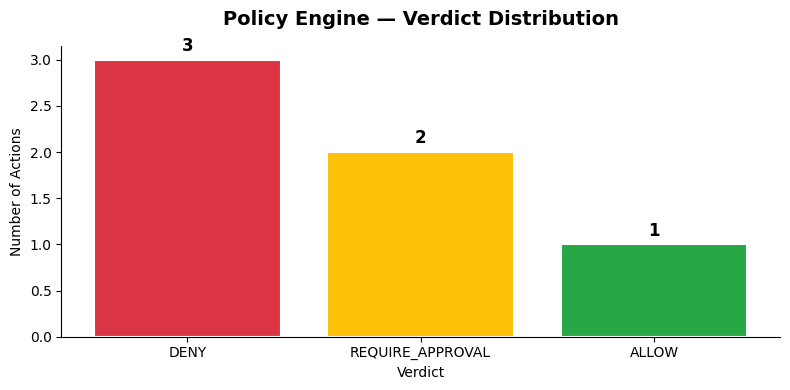

Default-deny is active — unknown actions are blocked, not silently permitted.


In [5]:
import matplotlib.pyplot as plt

verdict_counts = df_results['Verdict'].value_counts()
colors = {'ALLOW': '#28a745', 'DENY': '#dc3545', 'REQUIRE_APPROVAL': '#ffc107'}
bar_colors = [colors.get(v, '#6c757d') for v in verdict_counts.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(verdict_counts.index, verdict_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title('Policy Engine — Verdict Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Actions')
ax.set_xlabel('Verdict')
for bar, count in zip(bars, verdict_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print('Default-deny is active — unknown actions are blocked, not silently permitted.')